In [1]:
import os
from pathlib import Path

if os.environ.get("KAGGLE_KERNEL_RUN_TYPE"):
    try:
        import torch_geometric
    except Exception:
        get_ipython().run_line_magic("pip", "install -q torch-geometric")



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import json
import time

import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import KFold, train_test_split
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from torch_geometric.nn import GATConv
except Exception as exc:
    raise ImportError("torch_geometric is required. Please install it in Kaggle.") from exc


@dataclass
class ExperimentConfig:
    data_root: str = "/kaggle/input/datasets/minhthnglu/herb-disease-dataset/data"
    random_seed: int = 42
    n_folds: int = 5
    max_epochs: int = 500
    early_stopping_patience: int = 30
    early_stopping_min_delta: float = 1e-4
    val_ratio_in_trainval: float = 0.15
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    hidden_dim: int = 96
    out_dim: int = 64
    node_emb_dim: int = 96
    n_heads: int = 2
    topk_similarity: int = 20
    graph_pos_edge_cap: int = 300000
    eval_negative_ratio: float = 1.0
    max_positive_edges: Optional[int] = 300000
    contrastive_temperature: float = 0.2
    contrastive_weight: float = 0.1
    contrastive_max_pos: int = 1024
    dual_view_temperature: float = 0.2
    dual_view_weight: float = 0.15
    dual_view_max_nodes: int = 4096
    hard_negative_topk: int = 32
    hard_negative_weight: float = 0.25
    hard_negative_ratio: float = 1.0
    batch_size: int = 32768
    decision_threshold: float = 0.5
    use_amp: bool = True
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


config = ExperimentConfig()
print(config)
print("torch", torch.__version__, "device", config.device)

ExperimentConfig(data_root='/kaggle/input/datasets/minhthnglu/herb-disease-dataset/data', random_seed=42, n_folds=5, max_epochs=500, early_stopping_patience=30, early_stopping_min_delta=0.0001, val_ratio_in_trainval=0.15, learning_rate=0.001, weight_decay=1e-05, hidden_dim=96, out_dim=64, node_emb_dim=96, n_heads=2, topk_similarity=20, graph_pos_edge_cap=300000, eval_negative_ratio=1.0, max_positive_edges=300000, contrastive_temperature=0.2, contrastive_weight=0.1, contrastive_max_pos=1024, dual_view_temperature=0.2, dual_view_weight=0.15, dual_view_max_nodes=4096, hard_negative_topk=32, hard_negative_weight=0.25, hard_negative_ratio=1.0, batch_size=32768, decision_threshold=0.5, use_amp=True, device='cuda')
torch 2.10.0+cu128 device cuda


In [3]:
def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_core_data(data_root: str) -> Dict[str, object]:
    root = Path(data_root)
    processed = root / "processed"
    raw = root / "raw" / "icam_net"
    summary = json.loads((processed / "dataset_summary.json").read_text(encoding="utf-8"))
    R = sparse.load_npz(processed / "R_hd.npz").astype(np.float32).toarray()
    herb_index = pd.read_csv(processed / "herb_index.csv")
    disease_index = pd.read_csv(processed / "disease_index.csv")
    hc = pd.read_csv(raw / "H_C_TCM.csv", usecols=["herbid", "cid"])
    dp = pd.read_csv(raw / "D_P_TCM.csv", usecols=["diseaseId", "geneId"])
    return {
        "summary": summary,
        "R": R,
        "herb_index": herb_index,
        "disease_index": disease_index,
        "H_C": hc,
        "D_P": dp,
    }


def build_binary_profile(
    edge_df: pd.DataFrame,
    left_col: str,
    right_col: str,
    left_vocab: np.ndarray,
    right_vocab: np.ndarray,
) -> sparse.csr_matrix:
    left_map = {v: i for i, v in enumerate(left_vocab)}
    right_map = {v: i for i, v in enumerate(right_vocab)}
    l = edge_df[left_col].map(left_map)
    r = edge_df[right_col].map(right_map)
    mask = l.notna() & r.notna()
    l_idx = l[mask].to_numpy(dtype=np.int64)
    r_idx = r[mask].to_numpy(dtype=np.int64)
    data = np.ones(len(l_idx), dtype=np.float32)
    return sparse.csr_matrix((data, (l_idx, r_idx)), shape=(len(left_vocab), len(right_vocab)), dtype=np.float32)


def knn_from_profile(profile: sparse.csr_matrix, k: int) -> Tuple[np.ndarray, np.ndarray]:
    n = profile.shape[0]
    if n <= 1:
        return np.zeros((n, 0), dtype=np.int64), np.zeros((n, 0), dtype=np.float32)
    k_eff = max(1, min(k, n - 1))
    nn = NearestNeighbors(n_neighbors=k_eff + 1, metric="cosine", algorithm="brute", n_jobs=-1)
    nn.fit(profile)
    dists, inds = nn.kneighbors(profile, return_distance=True)
    inds = inds[:, 1:]
    dists = dists[:, 1:]
    sims = 1.0 - dists
    sims = np.clip(sims, 0.0, 1.0).astype(np.float32)
    return inds.astype(np.int64), sims


def gip_knn(interaction: np.ndarray, axis: int, k: int) -> Tuple[np.ndarray, np.ndarray]:
    x = interaction if axis == 0 else interaction.T
    x = x.astype(np.float32)
    n = x.shape[0]
    if n <= 1:
        return np.zeros((n, 0), dtype=np.int64), np.zeros((n, 0), dtype=np.float32)
    k_eff = max(1, min(k, n - 1))
    sq = np.sum(x * x, axis=1)
    gamma = 1.0 / np.mean(sq) if np.mean(sq) > 0 else 1.0
    nn = NearestNeighbors(n_neighbors=k_eff + 1, metric="euclidean", algorithm="brute", n_jobs=-1)
    nn.fit(x)
    dists, inds = nn.kneighbors(x, return_distance=True)
    inds = inds[:, 1:]
    d2 = dists[:, 1:] ** 2
    sims = np.exp(-gamma * d2).astype(np.float32)
    return inds.astype(np.int64), sims


def gip_similarity_matrix(interaction: np.ndarray, axis: int) -> np.ndarray:
    x = interaction if axis == 0 else interaction.T
    x = x.astype(np.float32)
    sq = np.sum(x * x, axis=1, keepdims=True)
    gram = x @ x.T
    d2 = np.maximum(sq + sq.T - 2.0 * gram, 0.0)
    gamma = 1.0 / float(np.mean(np.sum(x * x, axis=1))) if float(np.mean(np.sum(x * x, axis=1))) > 0 else 1.0
    sim = np.exp(-gamma * d2).astype(np.float32)
    np.fill_diagonal(sim, 1.0)
    return sim


def combine_knn_graph(
    base_idx: np.ndarray,
    base_w: np.ndarray,
    extra_idx: Optional[np.ndarray],
    extra_w: Optional[np.ndarray],
    alpha: float = 0.5,
) -> Tuple[np.ndarray, np.ndarray]:
    if extra_idx is None or extra_w is None:
        return base_idx, base_w
    n, k = base_idx.shape
    out_idx = np.zeros((n, k), dtype=np.int64)
    out_w = np.zeros((n, k), dtype=np.float32)
    for i in range(n):
        m = {}
        for j in range(k):
            nb = int(base_idx[i, j])
            m[nb] = m.get(nb, 0.0) + alpha * float(base_w[i, j])
        for j in range(k):
            nb = int(extra_idx[i, j])
            m[nb] = m.get(nb, 0.0) + (1.0 - alpha) * float(extra_w[i, j])
        items = sorted(m.items(), key=lambda t: t[1], reverse=True)[:k]
        out_idx[i, : len(items)] = [t[0] for t in items]
        out_w[i, : len(items)] = [t[1] for t in items]
    return out_idx, out_w


def build_adjacency_edge_index(
    R: np.ndarray,
    graph_pos_edge_cap: int,
    seed: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    n_herb, n_dis = R.shape
    rows = []
    cols = []
    vals = []

    rr, cc = np.nonzero(R > 0)
    if len(rr) > graph_pos_edge_cap:
        rng = np.random.default_rng(seed)
        keep = rng.choice(len(rr), size=graph_pos_edge_cap, replace=False)
        rr = rr[keep]
        cc = cc[keep]

    for a, b in zip(rr, cc):
        u = int(a)
        v = n_herb + int(b)
        rows.append(u)
        cols.append(v)
        vals.append(1.0)
        rows.append(v)
        cols.append(u)
        vals.append(1.0)

    if len(rows) == 0:
        n_nodes = n_herb + n_dis
        rows = list(range(n_nodes))
        cols = list(range(n_nodes))
        vals = [1.0] * n_nodes

    edge_index = torch.tensor(np.vstack([rows, cols]), dtype=torch.long)
    edge_weight = torch.tensor(np.asarray(vals, dtype=np.float32), dtype=torch.float32)
    return edge_index, edge_weight


def build_similarity_edge_index(
    herb_idx: np.ndarray,
    herb_w: np.ndarray,
    dis_idx: np.ndarray,
    dis_w: np.ndarray,
    n_herb: int,
    n_dis: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    rows = []
    cols = []
    vals = []

    if herb_idx.size > 0:
        k_h = herb_idx.shape[1]
        for i in range(n_herb):
            for t in range(k_h):
                j = int(herb_idx[i, t])
                w = float(herb_w[i, t])
                if w > 0:
                    rows.append(i)
                    cols.append(j)
                    vals.append(w)

    if dis_idx.size > 0:
        k_d = dis_idx.shape[1]
        for i in range(n_dis):
            for t in range(k_d):
                j = int(dis_idx[i, t])
                w = float(dis_w[i, t])
                if w > 0:
                    u = n_herb + i
                    v = n_herb + j
                    rows.append(u)
                    cols.append(v)
                    vals.append(w)

    if len(rows) == 0:
        n_nodes = n_herb + n_dis
        rows = list(range(n_nodes))
        cols = list(range(n_nodes))
        vals = [1.0] * n_nodes

    edge_index = torch.tensor(np.vstack([rows, cols]), dtype=torch.long)
    edge_weight = torch.tensor(np.asarray(vals, dtype=np.float32), dtype=torch.float32)
    return edge_index, edge_weight


def build_edge_index(
    R: np.ndarray,
    herb_idx: np.ndarray,
    herb_w: np.ndarray,
    dis_idx: np.ndarray,
    dis_w: np.ndarray,
    graph_pos_edge_cap: int,
    seed: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    adj_index, adj_weight = build_adjacency_edge_index(R, graph_pos_edge_cap=graph_pos_edge_cap, seed=seed)
    sim_index, sim_weight = build_similarity_edge_index(herb_idx, herb_w, dis_idx, dis_w, n_herb=R.shape[0], n_dis=R.shape[1])
    edge_index = torch.cat([adj_index, sim_index], dim=1)
    edge_weight = torch.cat([adj_weight, sim_weight], dim=0)
    return edge_index, edge_weight


def build_hard_negative_bank(R_train: np.ndarray, topk: int) -> List[np.ndarray]:
    dis_sim = gip_similarity_matrix(R_train, axis=1)
    n_herb, n_dis = R_train.shape
    bank: List[np.ndarray] = []
    for h in range(n_herb):
        pos = np.flatnonzero(R_train[h] > 0.5)
        if len(pos) == 0:
            bank.append(np.empty(0, dtype=np.int64))
            continue
        score = dis_sim[:, pos].max(axis=1)
        score[pos] = -np.inf
        valid = np.flatnonzero(np.isfinite(score))
        if len(valid) == 0:
            bank.append(np.empty(0, dtype=np.int64))
            continue
        take = min(topk, len(valid))
        part = valid[np.argpartition(score[valid], -take)[-take:]]
        order = part[np.argsort(score[part])[::-1]]
        bank.append(order.astype(np.int64))
    return bank


def sample_hard_negative_pairs(
    h_batch: np.ndarray,
    y_batch: np.ndarray,
    hard_bank: List[np.ndarray],
    ratio: float,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray]:
    if ratio <= 0:
        return np.empty(0, dtype=np.int64), np.empty(0, dtype=np.int64)
    pos_herbs = h_batch[y_batch > 0.5]
    if len(pos_herbs) == 0:
        return np.empty(0, dtype=np.int64), np.empty(0, dtype=np.int64)

    target = max(1, int(len(pos_herbs) * ratio))
    out_h = []
    out_d = []
    for _ in range(target):
        h = int(pos_herbs[rng.integers(0, len(pos_herbs))])
        cand = hard_bank[h]
        if len(cand) == 0:
            continue
        d = int(cand[rng.integers(0, len(cand))])
        out_h.append(h)
        out_d.append(d)

    if len(out_h) == 0:
        return np.empty(0, dtype=np.int64), np.empty(0, dtype=np.int64)
    return np.asarray(out_h, dtype=np.int64), np.asarray(out_d, dtype=np.int64)

In [4]:
class GATMDAScalable(nn.Module):
    def __init__(self, n_herb: int, n_dis: int, cfg: ExperimentConfig):
        super().__init__()
        self.n_herb = n_herb
        self.n_dis = n_dis
        self.n_nodes = n_herb + n_dis
        self.node_emb = nn.Embedding(self.n_nodes, cfg.node_emb_dim)
        self.gat1 = GATConv(cfg.node_emb_dim, cfg.hidden_dim, heads=cfg.n_heads, concat=False)
        self.gat2 = GATConv(cfg.hidden_dim, cfg.hidden_dim, heads=cfg.n_heads, concat=False)
        self.gat3 = GATConv(cfg.hidden_dim, cfg.out_dim, heads=cfg.n_heads, concat=False)
        self.proj_h = nn.Linear(cfg.out_dim, cfg.out_dim)
        self.proj_d = nn.Linear(cfg.out_dim, cfg.out_dim)
        self.fusion_gate = nn.Sequential(
            nn.Linear(cfg.out_dim * 2, cfg.out_dim),
            nn.ELU(),
            nn.Linear(cfg.out_dim, 2),
        )

    def encode_single(self, edge_index: torch.Tensor, edge_weight: torch.Tensor) -> torch.Tensor:
        x = self.node_emb.weight
        h = F.elu(self.gat1(x, edge_index, edge_weight))
        h = F.elu(self.gat2(h, edge_index, edge_weight))
        h = self.gat3(h, edge_index, edge_weight)
        return h

    def fuse_views(
        self,
        z_adj: torch.Tensor,
        z_sim: Optional[torch.Tensor],
        use_attention_fusion: bool,
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        if z_sim is None:
            return z_adj, None
        if use_attention_fusion:
            gate = torch.softmax(self.fusion_gate(torch.cat([z_adj, z_sim], dim=1)), dim=1)
            z = gate[:, :1] * z_adj + gate[:, 1:] * z_sim
            return z, gate
        return 0.5 * (z_adj + z_sim), None

    def encode(
        self,
        edge_index_adj: torch.Tensor,
        edge_weight_adj: torch.Tensor,
        edge_index_sim: Optional[torch.Tensor] = None,
        edge_weight_sim: Optional[torch.Tensor] = None,
        use_attention_fusion: bool = False,
    ) -> Tuple[torch.Tensor, torch.Tensor, Dict[str, Optional[torch.Tensor]]]:
        z_adj = self.encode_single(edge_index_adj, edge_weight_adj)
        z_sim = None
        if edge_index_sim is not None and edge_weight_sim is not None:
            z_sim = self.encode_single(edge_index_sim, edge_weight_sim)
        z_fused, gate = self.fuse_views(z_adj, z_sim, use_attention_fusion=use_attention_fusion)
        herb_z = self.proj_h(z_fused[: self.n_herb])
        dis_z = self.proj_d(z_fused[self.n_herb :])
        aux = {"z_adj": z_adj, "z_sim": z_sim, "fusion_gate": gate}
        return herb_z, dis_z, aux

    def score_pairs(self, herb_z: torch.Tensor, dis_z: torch.Tensor, herb_idx: torch.Tensor, dis_idx: torch.Tensor) -> torch.Tensor:
        a = herb_z[herb_idx]
        b = dis_z[dis_idx]
        return torch.sum(a * b, dim=1)


def compute_metrics(y_true: np.ndarray, y_score: np.ndarray, threshold: float) -> Dict[str, float]:
    y_pred = (y_score >= threshold).astype(np.int32)
    out = {
        "acc": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "auprc": float(average_precision_score(y_true, y_score)),
    }
    try:
        out["auroc"] = float(roc_auc_score(y_true, y_score))
    except Exception:
        out["auroc"] = float("nan")
    return out


def score_edge_batchwise(
    model: GATMDAScalable,
    edge_index_adj: torch.Tensor,
    edge_weight_adj: torch.Tensor,
    edge_index_sim: Optional[torch.Tensor],
    edge_weight_sim: Optional[torch.Tensor],
    use_attention_fusion: bool,
    eval_edges: np.ndarray,
    n_dis: int,
    device: torch.device,
    batch_size: int,
) -> np.ndarray:
    model.eval()
    scores = []
    with torch.no_grad():
        herb_z, dis_z, _ = model.encode(
            edge_index_adj=edge_index_adj,
            edge_weight_adj=edge_weight_adj,
            edge_index_sim=edge_index_sim,
            edge_weight_sim=edge_weight_sim,
            use_attention_fusion=use_attention_fusion,
        )
        for st in range(0, len(eval_edges), batch_size):
            ed = min(st + batch_size, len(eval_edges))
            e = eval_edges[st:ed]
            h_eval = torch.tensor((e // n_dis).astype(np.int64), dtype=torch.long, device=device)
            d_eval = torch.tensor((e % n_dis).astype(np.int64), dtype=torch.long, device=device)
            s = torch.sigmoid(model.score_pairs(herb_z, dis_z, h_eval, d_eval)).detach().cpu().numpy()
            scores.append(s)
    return np.concatenate(scores)


def contrastive_pair_loss(
    herb_z: torch.Tensor,
    dis_z: torch.Tensor,
    herb_idx: torch.Tensor,
    dis_idx: torch.Tensor,
    labels: torch.Tensor,
    temperature: float,
    max_pos: int,
) -> torch.Tensor:
    pos = torch.nonzero(labels > 0.5, as_tuple=False).squeeze(1)
    n_pos = int(pos.numel())
    if n_pos < 2:
        return herb_z.new_zeros(())
    if n_pos > max_pos:
        take = torch.randperm(n_pos, device=pos.device)[:max_pos]
        pos = pos[take]

    h_pos = F.normalize(herb_z[herb_idx[pos]], dim=1)
    d_pos = F.normalize(dis_z[dis_idx[pos]], dim=1)
    logits = (h_pos @ d_pos.T) / temperature
    targets = torch.arange(logits.size(0), device=logits.device)
    loss_hd = F.cross_entropy(logits, targets)
    loss_dh = F.cross_entropy(logits.T, targets)
    return 0.5 * (loss_hd + loss_dh)


def dual_view_contrastive_loss(
    z_adj: Optional[torch.Tensor],
    z_sim: Optional[torch.Tensor],
    temperature: float,
    max_nodes: int,
) -> torch.Tensor:
    if z_adj is None or z_sim is None:
        return torch.zeros((), device=z_adj.device if z_adj is not None else "cpu")
    n = z_adj.size(0)
    if n < 2:
        return z_adj.new_zeros(())
    if n > max_nodes:
        sel = torch.randperm(n, device=z_adj.device)[:max_nodes]
        a = z_adj[sel]
        b = z_sim[sel]
    else:
        a = z_adj
        b = z_sim

    a = F.normalize(a, dim=1)
    b = F.normalize(b, dim=1)
    logits = (a @ b.T) / temperature
    targets = torch.arange(logits.size(0), device=logits.device)
    loss_ab = F.cross_entropy(logits, targets)
    loss_ba = F.cross_entropy(logits.T, targets)
    return 0.5 * (loss_ab + loss_ba)


def train_single_fold(
    train_R: np.ndarray,
    train_edges: np.ndarray,
    train_labels: np.ndarray,
    val_edges: np.ndarray,
    val_labels: np.ndarray,
    test_edges: np.ndarray,
    herb_idx: np.ndarray,
    herb_w: np.ndarray,
    dis_idx: np.ndarray,
    dis_w: np.ndarray,
    use_contrastive: bool,
    use_dual_view_cl: bool,
    use_hard_negatives: bool,
    use_attention_fusion: bool,
    hard_negative_bank: Optional[List[np.ndarray]],
    cfg: ExperimentConfig,
    fold_seed: int,
) -> Tuple[np.ndarray, int, float]:
    device = torch.device(cfg.device)
    n_herb, n_dis = train_R.shape

    model = GATMDAScalable(n_herb, n_dis, cfg).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    amp_enabled = bool(cfg.use_amp and device.type == "cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    single_edge_index, single_edge_weight = build_edge_index(
        train_R,
        herb_idx,
        herb_w,
        dis_idx,
        dis_w,
        graph_pos_edge_cap=cfg.graph_pos_edge_cap,
        seed=fold_seed,
    )
    adj_edge_index, adj_edge_weight = build_adjacency_edge_index(
        train_R,
        graph_pos_edge_cap=cfg.graph_pos_edge_cap,
        seed=fold_seed,
    )
    sim_edge_index, sim_edge_weight = build_similarity_edge_index(
        herb_idx,
        herb_w,
        dis_idx,
        dis_w,
        n_herb=n_herb,
        n_dis=n_dis,
    )

    use_dual_graph = bool(use_dual_view_cl or use_attention_fusion)
    if use_dual_graph:
        edge_index_adj = adj_edge_index.to(device)
        edge_weight_adj = adj_edge_weight.to(device)
        edge_index_sim = sim_edge_index.to(device)
        edge_weight_sim = sim_edge_weight.to(device)
    else:
        edge_index_adj = single_edge_index.to(device)
        edge_weight_adj = single_edge_weight.to(device)
        edge_index_sim = None
        edge_weight_sim = None

    h_train = (train_edges // n_dis).astype(np.int64)
    d_train = (train_edges % n_dis).astype(np.int64)

    order = np.arange(len(train_edges))
    rng = np.random.default_rng(fold_seed)

    best_state = None
    best_val_auprc = -1.0
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, cfg.max_epochs + 1):
        rng.shuffle(order)
        model.train()

        for st in range(0, len(order), cfg.batch_size):
            ed = min(st + cfg.batch_size, len(order))
            b = order[st:ed]

            hb_np = h_train[b]
            db_np = d_train[b]
            yb_np = train_labels[b]

            hb = torch.tensor(hb_np, dtype=torch.long, device=device)
            db = torch.tensor(db_np, dtype=torch.long, device=device)
            yb = torch.tensor(yb_np, dtype=torch.float32, device=device)

            opt.zero_grad(set_to_none=True)
            try:
                if amp_enabled:
                    with torch.amp.autocast("cuda", enabled=True):
                        herb_z, dis_z, aux = model.encode(
                            edge_index_adj=edge_index_adj,
                            edge_weight_adj=edge_weight_adj,
                            edge_index_sim=edge_index_sim,
                            edge_weight_sim=edge_weight_sim,
                            use_attention_fusion=use_attention_fusion,
                        )
                        logit = model.score_pairs(herb_z, dis_z, hb, db)
                        loss = F.binary_cross_entropy_with_logits(logit, yb)

                        if use_contrastive:
                            loss = loss + cfg.contrastive_weight * contrastive_pair_loss(
                                herb_z,
                                dis_z,
                                hb,
                                db,
                                yb,
                                temperature=cfg.contrastive_temperature,
                                max_pos=cfg.contrastive_max_pos,
                            )

                        if use_dual_view_cl:
                            loss = loss + cfg.dual_view_weight * dual_view_contrastive_loss(
                                aux["z_adj"],
                                aux["z_sim"],
                                temperature=cfg.dual_view_temperature,
                                max_nodes=cfg.dual_view_max_nodes,
                            )

                        if use_hard_negatives and hard_negative_bank is not None:
                            h_hn_np, d_hn_np = sample_hard_negative_pairs(
                                hb_np,
                                yb_np,
                                hard_negative_bank,
                                ratio=cfg.hard_negative_ratio,
                                rng=rng,
                            )
                            if len(h_hn_np) > 0:
                                h_hn = torch.tensor(h_hn_np, dtype=torch.long, device=device)
                                d_hn = torch.tensor(d_hn_np, dtype=torch.long, device=device)
                                logit_hn = model.score_pairs(herb_z, dis_z, h_hn, d_hn)
                                y_hn = torch.zeros_like(logit_hn)
                                loss = loss + cfg.hard_negative_weight * F.binary_cross_entropy_with_logits(logit_hn, y_hn)
                    scaler.scale(loss).backward()
                    scaler.step(opt)
                    scaler.update()
                else:
                    herb_z, dis_z, aux = model.encode(
                        edge_index_adj=edge_index_adj,
                        edge_weight_adj=edge_weight_adj,
                        edge_index_sim=edge_index_sim,
                        edge_weight_sim=edge_weight_sim,
                        use_attention_fusion=use_attention_fusion,
                    )
                    logit = model.score_pairs(herb_z, dis_z, hb, db)
                    loss = F.binary_cross_entropy_with_logits(logit, yb)

                    if use_contrastive:
                        loss = loss + cfg.contrastive_weight * contrastive_pair_loss(
                            herb_z,
                            dis_z,
                            hb,
                            db,
                            yb,
                            temperature=cfg.contrastive_temperature,
                            max_pos=cfg.contrastive_max_pos,
                        )

                    if use_dual_view_cl:
                        loss = loss + cfg.dual_view_weight * dual_view_contrastive_loss(
                            aux["z_adj"],
                            aux["z_sim"],
                            temperature=cfg.dual_view_temperature,
                            max_nodes=cfg.dual_view_max_nodes,
                        )

                    if use_hard_negatives and hard_negative_bank is not None:
                        h_hn_np, d_hn_np = sample_hard_negative_pairs(
                            hb_np,
                            yb_np,
                            hard_negative_bank,
                            ratio=cfg.hard_negative_ratio,
                            rng=rng,
                        )
                        if len(h_hn_np) > 0:
                            h_hn = torch.tensor(h_hn_np, dtype=torch.long, device=device)
                            d_hn = torch.tensor(d_hn_np, dtype=torch.long, device=device)
                            logit_hn = model.score_pairs(herb_z, dis_z, h_hn, d_hn)
                            y_hn = torch.zeros_like(logit_hn)
                            loss = loss + cfg.hard_negative_weight * F.binary_cross_entropy_with_logits(logit_hn, y_hn)
                    loss.backward()
                    opt.step()
            except RuntimeError as e:
                if "out of memory" in str(e).lower() and device.type == "cuda":
                    torch.cuda.empty_cache()
                raise

        val_scores = score_edge_batchwise(
            model=model,
            edge_index_adj=edge_index_adj,
            edge_weight_adj=edge_weight_adj,
            edge_index_sim=edge_index_sim,
            edge_weight_sim=edge_weight_sim,
            use_attention_fusion=use_attention_fusion,
            eval_edges=val_edges,
            n_dis=n_dis,
            device=device,
            batch_size=cfg.batch_size,
        )
        val_metrics = compute_metrics(val_labels, val_scores, threshold=cfg.decision_threshold)
        val_auprc = val_metrics["auprc"]

        improved = val_auprc > (best_val_auprc + cfg.early_stopping_min_delta)
        if improved:
            best_val_auprc = val_auprc
            best_epoch = epoch
            bad_epochs = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1

        if bad_epochs >= cfg.early_stopping_patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_scores = score_edge_batchwise(
        model=model,
        edge_index_adj=edge_index_adj,
        edge_weight_adj=edge_weight_adj,
        edge_index_sim=edge_index_sim,
        edge_weight_sim=edge_weight_sim,
        use_attention_fusion=use_attention_fusion,
        eval_edges=test_edges,
        n_dis=n_dis,
        device=device,
        batch_size=cfg.batch_size,
    )

    if device.type == "cuda":
        torch.cuda.empty_cache()

    return test_scores, best_epoch, best_val_auprc

In [5]:
def prepare_knn_graphs(data_bundle: Dict[str, object], R_train: np.ndarray, k: int, use_extra_similarity: bool):
    herb_ids = data_bundle["herb_index"]["herbid"].to_numpy()
    dis_ids = data_bundle["disease_index"]["diseaseId"].to_numpy()

    comp_vocab = np.array(sorted(data_bundle["H_C"]["cid"].unique()))
    prot_vocab = np.array(sorted(data_bundle["D_P"]["geneId"].unique()))

    hc_profile = build_binary_profile(data_bundle["H_C"], "herbid", "cid", herb_ids, comp_vocab)
    dp_profile = build_binary_profile(data_bundle["D_P"], "diseaseId", "geneId", dis_ids, prot_vocab)

    h_idx_b, h_w_b = knn_from_profile(hc_profile, k)
    d_idx_b, d_w_b = knn_from_profile(dp_profile, k)

    if use_extra_similarity:
        h_idx_e, h_w_e = gip_knn(R_train, axis=0, k=k)
        d_idx_e, d_w_e = gip_knn(R_train, axis=1, k=k)
    else:
        h_idx_e, h_w_e = None, None
        d_idx_e, d_w_e = None, None

    h_idx, h_w = combine_knn_graph(h_idx_b, h_w_b, h_idx_e, h_w_e, alpha=0.5)
    d_idx, d_w = combine_knn_graph(d_idx_b, d_w_b, d_idx_e, d_w_e, alpha=0.5)
    return h_idx, h_w, d_idx, d_w


def collect_eval_edges(R: np.ndarray, cfg: ExperimentConfig):
    flat = R.reshape(-1)
    pos_idx = np.flatnonzero(flat == 1)
    neg_idx = np.flatnonzero(flat == 0)
    rng = np.random.default_rng(cfg.random_seed)

    if cfg.max_positive_edges is not None and len(pos_idx) > cfg.max_positive_edges:
        pos_idx = rng.choice(pos_idx, size=cfg.max_positive_edges, replace=False)

    neg_need = int(len(pos_idx) * cfg.eval_negative_ratio)
    neg_need = min(neg_need, len(neg_idx))
    neg_idx = rng.choice(neg_idx, size=neg_need, replace=False)

    eval_edges = np.concatenate([pos_idx, neg_idx])
    eval_labels = np.concatenate([
        np.ones(len(pos_idx), dtype=np.int32),
        np.zeros(len(neg_idx), dtype=np.int32),
    ])
    return eval_edges, eval_labels


def run_experiment(
    use_extra_similarity: bool,
    use_contrastive: bool,
    use_dual_view_cl: bool,
    use_hard_negatives: bool,
    use_attention_fusion: bool,
    k_similarity: int,
    cfg: ExperimentConfig,
):
    set_seed(cfg.random_seed)
    data_bundle = load_core_data(cfg.data_root)
    R = data_bundle["R"].astype(np.float32)

    eval_edges, eval_labels = collect_eval_edges(R, cfg)
    kf = KFold(n_splits=cfg.n_folds, shuffle=True, random_state=cfg.random_seed)

    all_true = []
    all_score = []
    fold_metrics = []

    config_name = (
        f"extra={int(use_extra_similarity)}|pair_cl={int(use_contrastive)}|"
        f"dual_cl={int(use_dual_view_cl)}|hard_neg={int(use_hard_negatives)}|"
        f"attn_fuse={int(use_attention_fusion)}|k={k_similarity}"
    )
    print(f"\n=== CONFIG {config_name} ===")

    for fold_id, (trainval_idx, test_idx) in enumerate(kf.split(eval_edges), start=1):
        t0 = time.time()
        fold_seed = cfg.random_seed + fold_id

        trainval_edges = eval_edges[trainval_idx]
        trainval_labels = eval_labels[trainval_idx]
        test_edges = eval_edges[test_idx]
        test_labels = eval_labels[test_idx]

        tr_idx, va_idx = train_test_split(
            np.arange(len(trainval_edges)),
            test_size=cfg.val_ratio_in_trainval,
            random_state=fold_seed,
            shuffle=True,
            stratify=trainval_labels,
        )

        train_edges = trainval_edges[tr_idx]
        train_labels = trainval_labels[tr_idx].astype(np.float32)
        val_edges = trainval_edges[va_idx]
        val_labels = trainval_labels[va_idx]

        train_R = R.copy()
        pos_test_edges = test_edges[test_labels == 1]
        pos_val_edges = val_edges[val_labels == 1]
        train_R.reshape(-1)[pos_test_edges] = 0.0
        train_R.reshape(-1)[pos_val_edges] = 0.0

        h_idx, h_w, d_idx, d_w = prepare_knn_graphs(
            data_bundle,
            train_R,
            k=cfg.topk_similarity,
            use_extra_similarity=use_extra_similarity,
        )

        hard_negative_bank = None
        if use_hard_negatives:
            hard_negative_bank = build_hard_negative_bank(train_R, topk=cfg.hard_negative_topk)

        try:
            test_scores, best_epoch, best_val_auprc = train_single_fold(
                train_R,
                train_edges=train_edges,
                train_labels=train_labels,
                val_edges=val_edges,
                val_labels=val_labels,
                test_edges=test_edges,
                herb_idx=h_idx,
                herb_w=h_w,
                dis_idx=d_idx,
                dis_w=d_w,
                use_contrastive=use_contrastive,
                use_dual_view_cl=use_dual_view_cl,
                use_hard_negatives=use_hard_negatives,
                use_attention_fusion=use_attention_fusion,
                hard_negative_bank=hard_negative_bank,
                cfg=cfg,
                fold_seed=fold_seed,
            )
        except RuntimeError as e:
            if "out of memory" in str(e).lower() and cfg.device.startswith("cuda"):
                print("OOM on GPU, retry fold on CPU with lower batch size")
                cpu_cfg = ExperimentConfig(
                    **{
                        **cfg.__dict__,
                        "device": "cpu",
                        "batch_size": max(4096, cfg.batch_size // 4),
                        "use_amp": False,
                    }
                )
                test_scores, best_epoch, best_val_auprc = train_single_fold(
                    train_R,
                    train_edges=train_edges,
                    train_labels=train_labels,
                    val_edges=val_edges,
                    val_labels=val_labels,
                    test_edges=test_edges,
                    herb_idx=h_idx,
                    herb_w=h_w,
                    dis_idx=d_idx,
                    dis_w=d_w,
                    use_contrastive=use_contrastive,
                    use_dual_view_cl=use_dual_view_cl,
                    use_hard_negatives=use_hard_negatives,
                    use_attention_fusion=use_attention_fusion,
                    hard_negative_bank=hard_negative_bank,
                    cfg=cpu_cfg,
                    fold_seed=fold_seed,
                )
            else:
                raise

        m = compute_metrics(test_labels, test_scores, threshold=cfg.decision_threshold)
        m["fold"] = fold_id
        m["best_epoch"] = best_epoch
        m["best_val_auprc"] = best_val_auprc
        m["seconds"] = time.time() - t0
        fold_metrics.append(m)
        all_true.append(test_labels)
        all_score.append(test_scores)

        print(
            f"fold={fold_id} stop_epoch={best_epoch} "
            f"acc={m['acc']:.4f} f1={m['f1']:.4f} precision={m['precision']:.4f} "
            f"recall={m['recall']:.4f} auprc={m['auprc']:.4f} auroc={m['auroc']:.4f}"
        )

    y_true = np.concatenate(all_true)
    y_score = np.concatenate(all_score)
    summary = compute_metrics(y_true, y_score, threshold=cfg.decision_threshold)
    fold_df = pd.DataFrame(fold_metrics)

    metric_cols = ["acc", "f1", "precision", "recall", "auprc", "auroc"]
    metric_mean = fold_df[metric_cols].mean(numeric_only=True)
    metric_std = fold_df[metric_cols].std(numeric_only=True)

    print(f"--- CONFIG SUMMARY {config_name} ---")
    for c in metric_cols:
        print(f"{c}: mean={metric_mean[c]:.4f}, std={metric_std[c]:.4f}")

    fpr, tpr, _ = roc_curve(y_true, y_score)
    pr_rec, pr_pre, _ = precision_recall_curve(y_true, y_score)

    return {
        "summary": summary,
        "fold_metrics": fold_df,
        "metric_mean": metric_mean.to_dict(),
        "metric_std": metric_std.to_dict(),
        "roc": (fpr, tpr),
        "pr": (pr_rec, pr_pre),
        "y_true": y_true,
        "y_score": y_score,
    }


def plot_curves(result: Dict[str, object], title: str) -> None:
    fpr, tpr = result["roc"]
    rec, pre = result["pr"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(fpr, tpr)
    axes[0].plot([0, 1], [0, 1], linestyle="--")
    axes[0].set_title(f"ROC | {title}")
    axes[0].set_xlabel("FPR")
    axes[0].set_ylabel("TPR")
    axes[1].plot(rec, pre)
    axes[1].set_title(f"PR | {title}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    plt.tight_layout()
    plt.show()


def main(
    use_extra_similarity: bool,
    use_contrastive: bool,
    use_dual_view_cl: bool,
    use_hard_negatives: bool,
    use_attention_fusion: bool,
    k_similarity: int = 20,
    n_folds: int = 5,
    max_positive_edges: Optional[int] = 300000,
    max_epochs: int = 30,
    batch_size: int = 32768,
    graph_pos_edge_cap: int = 300000,
    patience: int = 5,
    contrastive_temperature: float = 0.2,
    contrastive_weight: float = 0.1,
    contrastive_max_pos: int = 1024,
    dual_view_temperature: float = 0.2,
    dual_view_weight: float = 0.15,
    dual_view_max_nodes: int = 4096,
    hard_negative_topk: int = 32,
    hard_negative_weight: float = 0.25,
    hard_negative_ratio: float = 1.0,
):
    cfg = ExperimentConfig(
        n_folds=n_folds,
        max_positive_edges=max_positive_edges,
        topk_similarity=k_similarity,
        max_epochs=max_epochs,
        batch_size=batch_size,
        graph_pos_edge_cap=graph_pos_edge_cap,
        early_stopping_patience=patience,
        contrastive_temperature=contrastive_temperature,
        contrastive_weight=contrastive_weight,
        contrastive_max_pos=contrastive_max_pos,
        dual_view_temperature=dual_view_temperature,
        dual_view_weight=dual_view_weight,
        dual_view_max_nodes=dual_view_max_nodes,
        hard_negative_topk=hard_negative_topk,
        hard_negative_weight=hard_negative_weight,
        hard_negative_ratio=hard_negative_ratio,
    )

    result = run_experiment(
        use_extra_similarity=use_extra_similarity,
        use_contrastive=use_contrastive,
        use_dual_view_cl=use_dual_view_cl,
        use_hard_negatives=use_hard_negatives,
        use_attention_fusion=use_attention_fusion,
        k_similarity=k_similarity,
        cfg=cfg,
    )

    title = (
        f"extra={int(use_extra_similarity)} | pair_cl={int(use_contrastive)} | "
        f"dual_cl={int(use_dual_view_cl)} | hard_neg={int(use_hard_negatives)} | "
        f"attn_fuse={int(use_attention_fusion)} | k={k_similarity}"
    )
    plot_curves(result, title)
    return result


def run_ablation(
    k_similarity: int = 20,
    n_folds: int = 5,
    max_positive_edges: Optional[int] = 300000,
    max_epochs: int = 30,
    batch_size: int = 32768,
    graph_pos_edge_cap: int = 300000,
    patience: int = 5,
    contrastive_temperature: float = 0.2,
    contrastive_weight: float = 0.1,
    contrastive_max_pos: int = 1024,
    dual_view_temperature: float = 0.2,
    dual_view_weight: float = 0.15,
    dual_view_max_nodes: int = 4096,
    hard_negative_topk: int = 32,
    hard_negative_weight: float = 0.25,
    hard_negative_ratio: float = 1.0,
):
    cases = [
        # {
        #     "case": "baseline",
        #     "use_extra_similarity": False,
        #     "use_contrastive": False,
        #     "use_dual_view_cl": False,
        #     "use_hard_negatives": False,
        #     "use_attention_fusion": False,
        # },
        # {
        #     "case": "extra_only",
        #     "use_extra_similarity": True,
        #     "use_contrastive": False,
        #     "use_dual_view_cl": False,
        #     "use_hard_negatives": False,
        #     "use_attention_fusion": False,
        # },
        # {
        #     "case": "dual_view_only",
        #     "use_extra_similarity": True,
        #     "use_contrastive": False,
        #     "use_dual_view_cl": True,
        #     "use_hard_negatives": False,
        #     "use_attention_fusion": False,
        # },
        # {
        #     "case": "hard_negative_only",
        #     "use_extra_similarity": True,
        #     "use_contrastive": False,
        #     "use_dual_view_cl": False,
        #     "use_hard_negatives": True,
        #     "use_attention_fusion": False,
        # },
        # {
        #     "case": "attention_only",
        #     "use_extra_similarity": True,
        #     "use_contrastive": False,
        #     "use_dual_view_cl": False,
        #     "use_hard_negatives": False,
        #     "use_attention_fusion": True,
        # },
        {
            "case": "full_proposed",
            "use_extra_similarity": True,
            "use_contrastive": True,
            "use_dual_view_cl": True,
            "use_hard_negatives": False,
            "use_attention_fusion": True,
        },
    ]

    records = []
    outputs = {}
    for cfg_case in cases:
        res = main(
            use_extra_similarity=cfg_case["use_extra_similarity"],
            use_contrastive=cfg_case["use_contrastive"],
            use_dual_view_cl=cfg_case["use_dual_view_cl"],
            use_hard_negatives=cfg_case["use_hard_negatives"],
            use_attention_fusion=cfg_case["use_attention_fusion"],
            k_similarity=k_similarity,
            n_folds=n_folds,
            max_positive_edges=max_positive_edges,
            max_epochs=max_epochs,
            batch_size=batch_size,
            graph_pos_edge_cap=graph_pos_edge_cap,
            patience=patience,
            contrastive_temperature=contrastive_temperature,
            contrastive_weight=contrastive_weight,
            contrastive_max_pos=contrastive_max_pos,
            dual_view_temperature=dual_view_temperature,
            dual_view_weight=dual_view_weight,
            dual_view_max_nodes=dual_view_max_nodes,
            hard_negative_topk=hard_negative_topk,
            hard_negative_weight=hard_negative_weight,
            hard_negative_ratio=hard_negative_ratio,
        )

        case_name = cfg_case["case"]
        outputs[case_name] = res
        row = {
            "case": case_name,
            "use_extra_similarity": int(cfg_case["use_extra_similarity"]),
            "use_contrastive": int(cfg_case["use_contrastive"]),
            "use_dual_view_cl": int(cfg_case["use_dual_view_cl"]),
            "use_hard_negatives": int(cfg_case["use_hard_negatives"]),
            "use_attention_fusion": int(cfg_case["use_attention_fusion"]),
            "k_similarity": k_similarity,
        }
        row.update(res["summary"])
        records.append(row)

    table = pd.DataFrame(records)
    return table, outputs


=== CONFIG extra=1|pair_cl=1|dual_cl=1|hard_neg=0|attn_fuse=1|k=25 ===
fold=1 stop_epoch=59 acc=0.9018 f1=0.9027 precision=0.8940 recall=0.9116 auprc=0.9666 auroc=0.9662
fold=2 stop_epoch=59 acc=0.8989 f1=0.9000 precision=0.8898 recall=0.9104 auprc=0.9653 auroc=0.9651
fold=3 stop_epoch=60 acc=0.8998 f1=0.9010 precision=0.8921 recall=0.9101 auprc=0.9656 auroc=0.9648
fold=4 stop_epoch=60 acc=0.8835 f1=0.8856 precision=0.8691 recall=0.9029 auprc=0.9544 auroc=0.9552
fold=5 stop_epoch=59 acc=0.8974 f1=0.8984 precision=0.8896 recall=0.9073 auprc=0.9651 auroc=0.9648
--- CONFIG SUMMARY extra=1|pair_cl=1|dual_cl=1|hard_neg=0|attn_fuse=1|k=25 ---
acc: mean=0.8963, std=0.0073
f1: mean=0.8975, std=0.0068
precision: mean=0.8869, std=0.0101
recall: mean=0.9084, std=0.0035
auprc: mean=0.9634, std=0.0051
auroc: mean=0.9632, std=0.0045


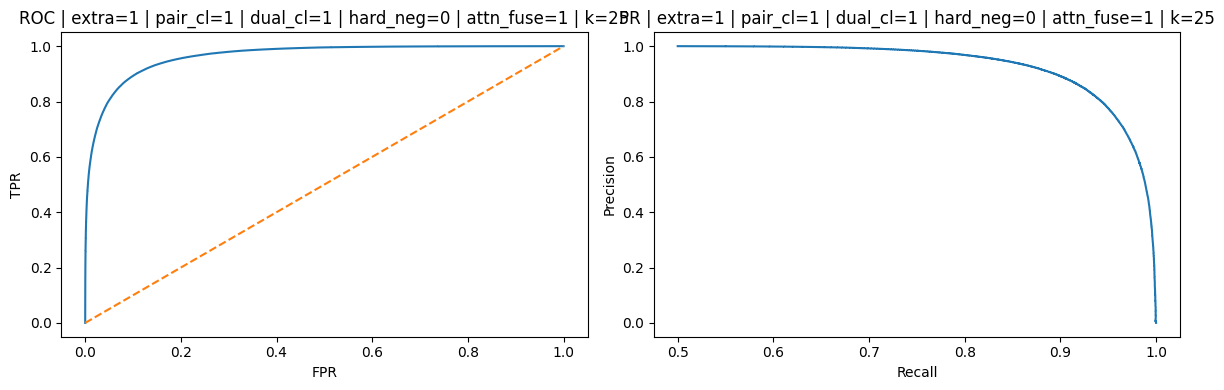

,case,use_extra_similarity,use_contrastive,use_dual_view_cl,use_hard_negatives,use_attention_fusion,k_similarity,acc,f1,precision,recall,auprc,auroc
0,full_proposed,1,1,1,0,1,25,0.896277,0.897523,0.886863,0.908443,0.963542,0.963333


In [6]:
output_dir = Path("/kaggle/working/gathda/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

ablation_table, ablation_outputs = run_ablation(
    k_similarity=25,
    n_folds=5,
    max_positive_edges=300000,
    max_epochs=60,
    batch_size=24576,
    graph_pos_edge_cap=300000,
    patience=8,
    contrastive_temperature=0.2,
    contrastive_weight=0.12,
    contrastive_max_pos=1536,
    dual_view_temperature=0.2,
    dual_view_weight=0.22,
    dual_view_max_nodes=6144,
    hard_negative_topk=48,
    hard_negative_weight=0.3,
    hard_negative_ratio=1.25,
)

case_order = [
    "baseline",
    "extra_only",
    "dual_view_only",
    "hard_negative_only",
    "attention_only",
    "full_proposed",
]
ablation_table["case"] = pd.Categorical(ablation_table["case"], categories=case_order, ordered=True)
ablation_table = ablation_table.sort_values("case").reset_index(drop=True)
ablation_table.to_csv(output_dir / "ablation_summary.csv", index=False)

for case, res in ablation_outputs.items():
    res["fold_metrics"].to_csv(output_dir / f"fold_metrics_{case}.csv", index=False)
    np.savez_compressed(
        output_dir / f"predictions_{case}.npz",
        y_true=res["y_true"],
        y_score=res["y_score"],
    )

ablation_table[[
    "case",
    "use_extra_similarity",
    "use_contrastive",
    "use_dual_view_cl",
    "use_hard_negatives",
    "use_attention_fusion",
    "k_similarity",
    "acc",
    "f1",
    "precision",
    "recall",
    "auprc",
    "auroc",
]]